# Second case: the tier's question and Marketing's pushback, argued from the same numbers

**Week 1, Tuesday afternoon. The second case, in pairs, forty minutes.** One of you answers Marketing,
the other answers the head of Retail-Plus, from the same file, and together you write the reply.

> **Marketing comes back with a new deck.** "Student orders per customer rose 40 percent after our
> campus push, so acquisition works. And Retail-Plus web orders fell hardest, 24 to 9, so this is the
> website team's problem, not the tier's and not the app's."
>
> The marketing lead, Kalpa Retail

> **The tier asks.** "Fine. Which of my members do I call first?"
>
> The head of Retail-Plus

> **Kavya's review of the escalated case.** "You found a branch that moved for a reason nobody
> guessed. Do the same with Marketing's two new numbers: find what each is made of before you agree
> or disagree."

This is the solution twin: every placeholder is filled, every cell has run, and under each step a
line says why the other three options fail.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers if customers else 0,
            "revenue_per_order": revenue / orders if orders else 0}


def pct_change(before, after):
    """Chapter 5's fixed helper: the change every time, in the same type."""
    return round(100 * (after - before) / before, 1)

print(len(ORDERS), "orders loaded")

200 orders loaded


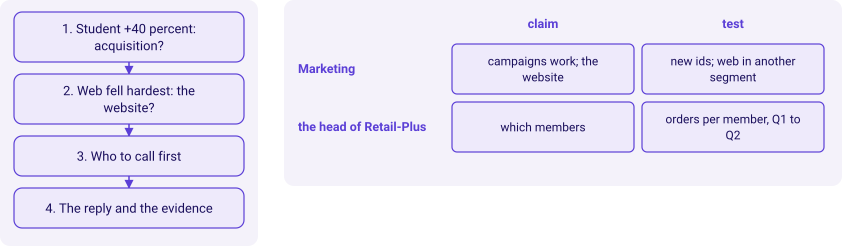

In [2]:
kit.side_by_side(
    kit.ladder(["Student +40 percent: acquisition?", "Web fell hardest: the website?",
                "Who to call first", "The reply and the evidence"], show=False),
    kit.matrix(["Marketing", "the head of Retail-Plus"], ["claim", "test"],
               [["campaigns work; the website", "new ids; web in another segment"], ["which members", "orders per member, Q1 to Q2"]],
               show=False),
)

## Part 1. "Student orders per customer rose 40 percent, so acquisition works"

Acquisition means new customers. Count the Student ids in each quarter and the ones that are new.

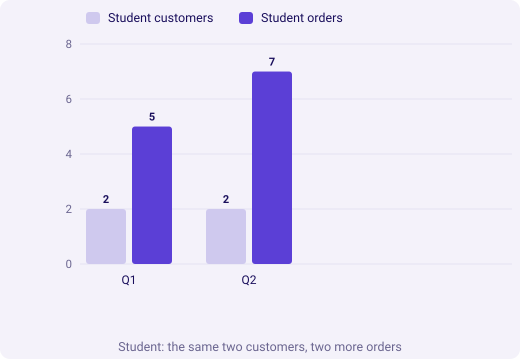

In [3]:
s_ids = {q: {o["customer_id"] for o in ORDERS if o["segment"] == "Student" and o["quarter"] == q} for q in ("Q1", "Q2")}
s_orders = {q: sum(1 for o in ORDERS if o["segment"] == "Student" and o["quarter"] == q) for q in ("Q1", "Q2")}
# TODO 1. Which set holds the Student customers who are new in Q2?
#   a) s_ids["Q2"] - s_ids["Q1"]
#   b) s_ids["Q1"] | s_ids["Q2"]
#   c) s_ids["Q1"] & s_ids["Q2"]
#   d) len(s_ids["Q2"]) - len(s_ids["Q1"])
new_students = s_ids["Q2"] - s_ids["Q1"]
kit.columns(["Q1", "Q2"], [("Student customers", [len(s_ids["Q1"]), len(s_ids["Q2"])]), ("Student orders", [s_orders["Q1"], s_orders["Q2"]])],
            width=520, title="Student: the same two customers, two more orders")
kit.check("no Student customer is new in Q2", isinstance(new_students, set) and len(new_students) == 0)
kit.check("the Student counts match the file", (s_orders["Q1"], s_orders["Q2"], len(s_ids["Q2"])) == (5, 7, 2))

**Why the other three fail.** b) is every Student id in either quarter. c) is the ones in both quarters. d)
is a difference of counts, which is zero whether or not anyone is new.

**The answer to Marketing.** The 40 percent is two more orders from the same two students. It adds no
customer, so it says nothing for acquisition, and on two customers one more order moves the rate by 0.5 orders per customer, 20 percent.

## Part 2. "Retail-Plus web orders fell hardest, so it is the website"

A broken website hurts every customer who uses it. If the website were the cause, what would another
segment's web orders show?

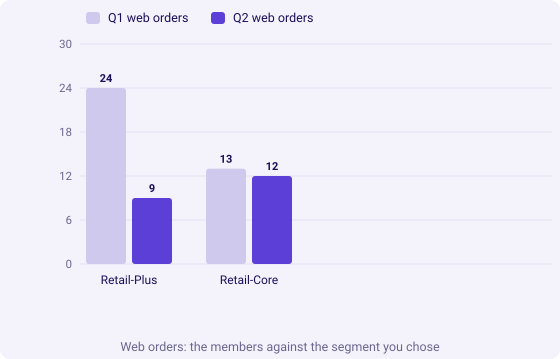

In [4]:
web = {(o["segment"], o["quarter"]): 0 for o in ORDERS}
for o in ORDERS:
    if o["channel"] == "web":
        web[(o["segment"], o["quarter"])] += 1
# TODO 2. If the website were broken for everyone, which other segment's web orders would also have fallen hard?
#   a) "Retail-Plus"
#   b) "Student"
#   c) "Retail-Core"
#   d) "none"
also_falls = "Retail-Core"
picked = also_falls if also_falls in SEGMENTS else "Retail-Plus"
kit.columns(["Retail-Plus", picked], [("Q1 web orders", [web[("Retail-Plus", "Q1")], web[(picked, "Q1")]]),
                                      ("Q2 web orders", [web[("Retail-Plus", "Q2")], web[(picked, "Q2")]])],
            width=560, title="Web orders: the members against the segment you chose")
kit.check("the comparison segment is another segment with enough web orders to read",
          also_falls in SEGMENTS and also_falls != "Retail-Plus" and web[(also_falls, "Q1")] >= 10)
kit.check("its web orders held, moving by at most one on the same website",
          also_falls in SEGMENTS and abs(web[(also_falls, "Q1")] - web[(also_falls, "Q2")]) <= 1)
kit.check("Retail-Plus web orders fell 24 to 9", (web[("Retail-Plus", "Q1")], web[("Retail-Plus", "Q2")]) == (24, 9))

**Why the other three fail.** a) is the pattern Marketing already saw; it cannot tell a website fault
from anything else that hits members. b) Student has one web order in Q1, too few to read. d) a
website fault shows on the website.

**The answer to Marketing.** Retail-Core's web orders held at 13 and 12 on the same website, so a
site-wide fault does not fit. Something hit members, on every channel: chapter 6 showed the store and
the app fell too.

## Part 3. "Which of my members do I call first?"

Count each member's orders in Q1 and Q2, and put the members who slowed most at the top of the list.

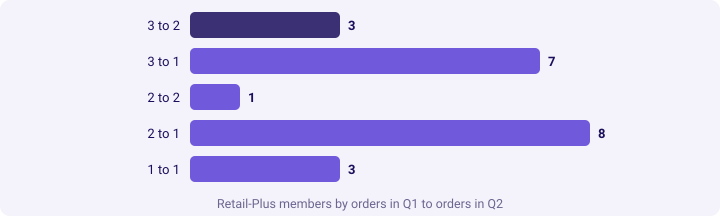

In [5]:
per = {q: {} for q in ("Q1", "Q2")}
for o in ORDERS:
    if o["segment"] == "Retail-Plus":
        per[o["quarter"]][o["customer_id"]] = per[o["quarter"]].get(o["customer_id"], 0) + 1
pairs = {}
for cid in per["Q1"]:
    key = (per["Q1"][cid], per["Q2"].get(cid, 0))
    pairs[key] = pairs.get(key, 0) + 1
call_first = []
for cid in per["Q1"]:
    q1n, q2n = per["Q1"][cid], per["Q2"].get(cid, 0)
    # TODO 3. Which members go to the top of the call list?
    #   a) q2n == 0
    #   b) q1n - q2n >= 2
    #   c) q2n > q1n
    #   d) q1n == 1
    if q1n - q2n >= 2:
        call_first.append(cid)
labels = [f"{a} to {b}" for a, b in sorted(pairs, reverse=True)]
kit.bars([(l, pairs[k]) for l, k in zip(labels, sorted(pairs, reverse=True))], lit=[0],
         title="Retail-Plus members by orders in Q1 to orders in Q2")
kit.check("the call list matches the Q1-to-Q2 counts", len(call_first) == pairs.get((3, 1), 0) + pairs.get((2, 0), 0) + pairs.get((3, 0), 0))
kit.check("every member still ordered in Q2", all(per["Q2"].get(c, 0) > 0 for c in per["Q1"]))

**Why the other three fail.** a) selects nobody, since every member ordered in Q2. c) selects the
members who grew, and there are none. d) selects the members who ordered once in Q1, the ones with
least to lose.

**The answer to the head of Retail-Plus.** Seven members went from three orders a quarter to one;
call them first, and ask each whether they tried to reorder and what happened. Eleven more fell by
one order. Nobody stopped altogether, which fits a habit that broke more than a tier people left.

## Part 4. The reply, and the one request that tests the most

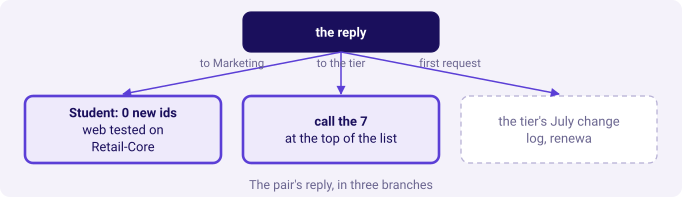

In [6]:
EVIDENCE = {
    "campaigns": "Marketing's campaign reach by month for the July student push",
    "export": "this export again, cut by city, channel and week from July",
    "app_logs": "the app's reorder logs by week since the 25 August release",
    "tier_log": "the tier's July change log, renewals and support tickets",
}
STARTS = {"campaigns": "2026-07-01", "export": "2026-04-01", "app_logs": "2026-08-25", "tier_log": "2026-07-01"}
FALL_BEGAN = "2026-07-31"
# TODO 4. The fall began in July and the button broke on 25 August. Which request tests the cause behind the larger part of the fall?
#   a) "campaigns"
#   b) "export"
#   c) "app_logs"
#   d) "tier_log"
first_request = "tier_log"
kit.tree({"label": "the reply", "kind": "lit", "branches": [
    ("to Marketing", {"label": f"Student: {len(new_students)} new ids\nweb tested on {also_falls}", "kind": "known"}),
    ("to the tier", {"label": f"call the {len(call_first)}\nat the top of the list", "kind": "known"}),
    ("first request", {"label": EVIDENCE[first_request][:34], "kind": "unknown"})]},
    title="The pair's reply, in three branches")
kit.check("the request's data starts by the month the fall began", STARTS[first_request] <= FALL_BEGAN, STARTS[first_request])
kit.check("the request tests a cause inside the tier", first_request not in ("export", "campaigns"))

**Why the other three fail.** a) measures acquisition, which Part 1 and chapter 5 ruled out. b) is
the data that raised the question. c) settles the button, which chapter 6 capped at about 4 orders
after 25 August, the smaller part.

**The pair's reply.** "To Marketing: Student's 40 percent is two more orders from the same two
customers, so it adds no evidence for acquisition, and Retail-Core's web orders held at 13 and 12 on
the same website, so a site-wide fault does not fit. To the head of Retail-Plus: call the seven members
who went from three orders to one first, and ask what changed for them in July. We are asking for the
tier's July change log, renewals and support tickets first, and the app's reorder logs second."

### In the interview

**[D] A stakeholder quotes a 40 percent rise; what do you ask before you react?** "What it is a rate
of, over how many, and whether the rise is new people or the same people doing more. Here it was two
customers placing seven orders against five, so one order moves it by 20 percent." The interviewer is
listening for the denominator first.

In [7]:
kit.check_summary()
print("Answer string for the TODOs: a c b d.")

Answer string for the TODOs: a c b d.
